# final project "Telco Customer Churn"
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." 

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


from sklearn.model_selection import GridSearchCV

In [5]:
df=pd.read_csv(r'C:\creativa_datasets\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
df.shape

(7043, 21)

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


| اسم العمود           | الوصف                                                                              |
| -------------------- | ------------------------------------------------------------------------------------------ |
| **customerID**       | رقم أو معرف فريد لكل عميل.                                                                 |
| **gender**           | جنس العميل (ذكر أو أنثى).                                                                  |
| **SeniorCitizen**    | يوضح ما إذا كان العميل من كبار السن (1 = نعم، 0 = لا).                                     |
| **Partner**          | هل لدى العميل شريك/زوج؟ (Yes / No).                                                        |
| **Dependents**       | هل لدى العميل أشخاص يعتمدون عليه (مثل الأطفال أو أفراد الأسرة)؟ (Yes / No).                |
| **tenure**           | عدد الأشهر التي قضاها العميل مشتركًا في الشركة.                                            |
| **PhoneService**     | هل يشترك العميل في خدمة الهاتف؟ (Yes / No).                                                |
| **MultipleLines**    | هل يمتلك العميل أكثر من خط هاتف؟ (Yes / No / No phone service).                            |
| **InternetService**  | نوع خدمة الإنترنت التي يستخدمها العميل (DSL، Fiber Optic، أو لا توجد خدمة).                |
| **OnlineSecurity**   | هل يشترك العميل في خدمة الأمان والحماية عبر الإنترنت؟ (Yes / No / No internet service).    |
| **OnlineBackup**     | هل يستخدم العميل خدمة النسخ الاحتياطي عبر الإنترنت؟ (Yes / No / No internet service).      |
| **DeviceProtection** | هل يشترك العميل في خدمة حماية الأجهزة؟ (Yes / No / No internet service).                   |
| **TechSupport**      | هل يحصل العميل على خدمة الدعم الفني؟ (Yes / No / No internet service).                     |
| **StreamingTV**      | هل يستخدم العميل خدمة بث القنوات التلفزيونية؟ (Yes / No / No internet service).            |
| **StreamingMovies**  | هل يستخدم العميل خدمة بث الأفلام؟ (Yes / No / No internet service).                        |
| **Contract**         | نوع عقد الاشتراك (شهري، سنة، أو سنتان).                                                    |
| **PaperlessBilling** | هل يستلم العميل الفواتير إلكترونيًا بدلًا من الورقية؟ (Yes / No).                          |
| **PaymentMethod**    | طريقة الدفع التي يستخدمها العميل (بطاقة ائتمان، تحويل بنكي، شيك إلكتروني، إلخ).            |
| **MonthlyCharges**   | قيمة الرسوم الشهرية التي يدفعها العميل مقابل الخدمات.                                      |
| **TotalCharges**     | إجمالي المبلغ الذي دفعه العميل منذ بداية الاشتراك.                                         |
| **Churn**            | المتغير المستهدف (Target): هل غادر العميل الشركة أم لا؟ (Yes = غادر، No = لا يزال عميلًا). |


In [8]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### data cleaning

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df[df.duplicated()]==True

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [11]:
df = df.drop('customerID', axis=1)

In [12]:
print(df.duplicated().sum()) 

22


In [13]:
df = df.drop_duplicates()
print(df.shape)  

(7021, 20)


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [16]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [17]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

#####  there are nulls in total charges, fix null by filling with 0 because these are new customers

## EDA

In [18]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']
cat_cols=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']
binary_cols = ['SeniorCitizen']
#skip churn to avoid data leakage

In [19]:
for i in cat_cols:
    print(df[i].unique())
    

['Female' 'Male']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


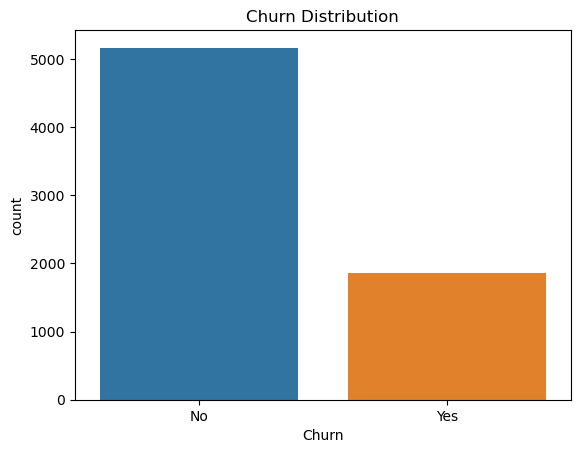

In [20]:
## EDA .check for class imbalance in the target variable

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

Not balanced

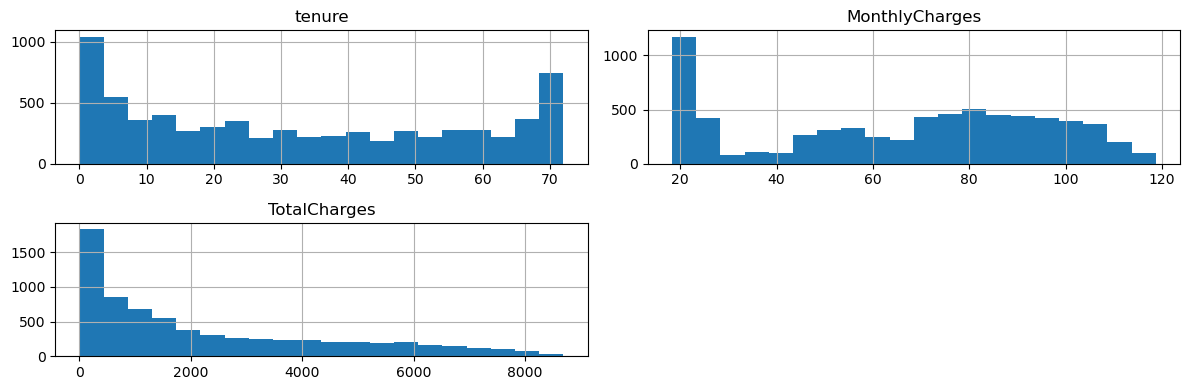

In [21]:
# check for numerical columns distribution

df[num_cols].hist(figsize=(12,4), bins=20)
plt.tight_layout()
plt.show()

d:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


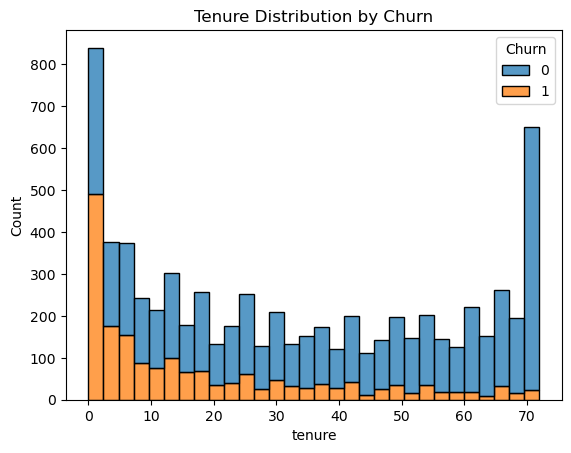

In [47]:
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Tenure Distribution by Churn')
plt.show()

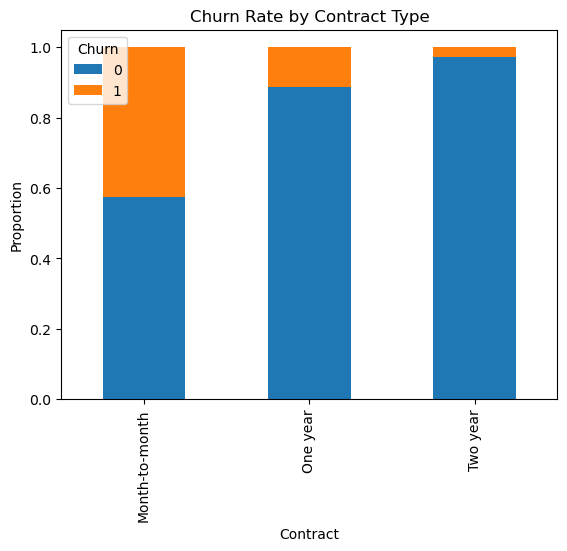

In [49]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion')
plt.show()

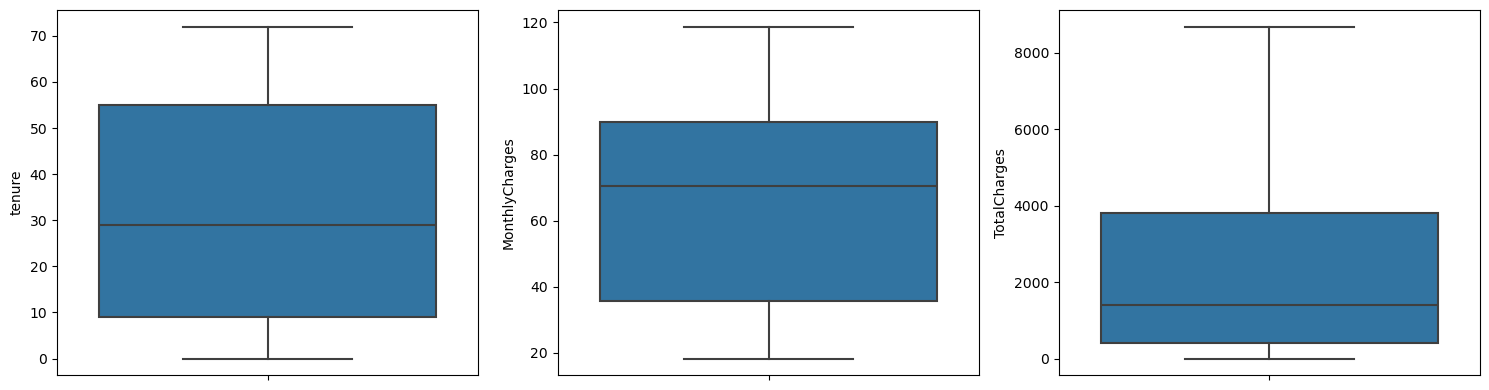

In [22]:
## check for outliers in the dataset

plt.figure(figsize=(15,4))

for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

No outliers

In [23]:
print(df[num_cols].corr())
print(df[num_cols].dtypes)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.245251      0.825595
MonthlyCharges  0.245251        1.000000      0.650653
TotalCharges    0.825595        0.650653      1.000000
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object


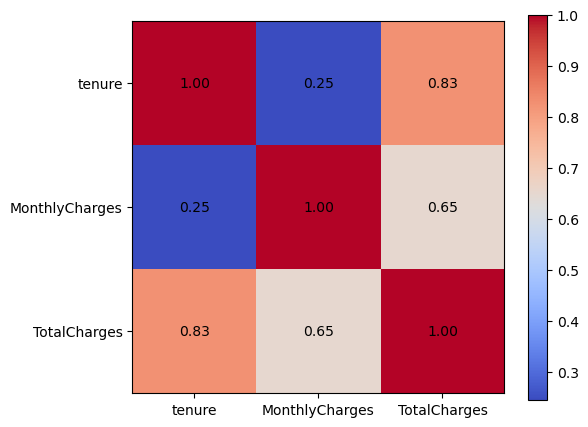

In [24]:
corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.show()

In [25]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## Train test split

In [34]:
# 1. Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)



In [27]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.735577
1    0.264423
Name: proportion, dtype: float64
Churn
0    0.735231
1    0.264769
Name: proportion, dtype: float64


## Encoding

In [32]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_train = encoder.fit_transform(X_train[cat_cols])
encoded_test = encoder.transform(X_test[cat_cols])  

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cat_cols), index=X_test.index)

X_train_encoded = pd.concat([X_train.drop(columns=cat_cols), encoded_train_df], axis=1)
X_test_encoded = pd.concat([X_test.drop(columns=cat_cols), encoded_test_df], axis=1)

## scalling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_encoded[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_encoded[num_cols] = scaler.transform(X_test_encoded[num_cols])  

## models

In [38]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    "SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1)
}

In [39]:
results = []

for name, model in models.items():
    # Fit
    model.fit(X_train_encoded, y_train)
    
    # Predict
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    
    # Metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False))

d:\anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:05:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
   Logistic Regression  0.802135   0.659864 0.521505  0.582583 0.840413
           Naive Bayes  0.651246   0.423377 0.876344  0.570928 0.807806
     Gradient Boosting  0.800712   0.665468 0.497312  0.569231 0.837392
              CatBoost  0.795018   0.646853 0.497312  0.562310 0.839351
              AdaBoost  0.792171   0.636054 0.502688  0.561562 0.836057
                   SVC  0.797153   0.665399 0.470430  0.551181 0.783134
Hist Gradient Boosting  0.786477   0.624138 0.486559  0.546828 0.830606
               XGBoost  0.777224   0.594855 0.497312  0.541728 0.818041
                   KNN  0.761566   0.556923 0.486559  0.519369 0.778176
         Random Forest  0.782206   0.627907 0.435484  0.514286 0.815841
           Extra Trees  0.765836   0.577617 0.430108  0.493066 0.785879
         Decision Tree  0.722420   0.476316 0.486559  0.481383 0.648043


## After target class balancing

In [ ]:
# Compute scale_pos_weight for XGBoost (its equivalent of class_weight)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models_balanced = {
    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1, class_weight='balanced'),

    
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    "SVC": SVC(probability=True, random_state=1, class_weight='balanced'),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1, class_weight='balanced'),

    # Naive Bayes 
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1, class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1, class_weight='balanced'),

    # Boosting — sklearn versions have no class_weight param, kept as-is
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries — different balancing syntax each
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, scale_pos_weight=scale_pos_weight),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1, auto_class_weights='Balanced')
}

results_balanced = []

for name, model in models_balanced.items():
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    
    results_balanced.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_balanced_df = pd.DataFrame(results_balanced).sort_values('F1-Score', ascending=False)
print(results_balanced_df.to_string(index=False))

                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
              CatBoost  0.774377   0.554890 0.747312  0.636884 0.840475
                   SVC  0.755160   0.525362 0.779570  0.627706 0.825673
   Logistic Regression  0.740925   0.506993 0.779570  0.614407 0.839817
               XGBoost  0.758007   0.536364 0.634409  0.581281 0.818023
           Naive Bayes  0.651246   0.423377 0.876344  0.570928 0.807806
     Gradient Boosting  0.800712   0.665468 0.497312  0.569231 0.837392
              AdaBoost  0.792171   0.636054 0.502688  0.561562 0.836057
Hist Gradient Boosting  0.786477   0.624138 0.486559  0.546828 0.830606
                   KNN  0.761566   0.556923 0.486559  0.519369 0.778176
         Random Forest  0.773665   0.601504 0.430108  0.501567 0.812148
           Extra Trees  0.762278   0.570370 0.413978  0.479751 0.783411
         Decision Tree  0.724555   0.479224 0.465054  0.472033 0.641755


## Grid search

In [42]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 500],
    'l2_leaf_reg': [1, 3, 5]
}

cat_model = CatBoostClassifier(verbose=0, random_state=1, auto_class_weights='Balanced')

grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring='f1',        # or 'roc_auc' — pick whichever metric matters most to you
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_encoded, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
Best CV F1 score: 0.6344570976106567


## feature selection

                                  Feature  Importance
1                                  tenure   18.615268
25                      Contract_Two year   13.434679
3                            TotalCharges    8.376644
10            InternetService_Fiber optic    7.965361
2                          MonthlyCharges    7.086950
24                      Contract_One year    5.760918
26                   PaperlessBilling_Yes    3.735231
28         PaymentMethod_Electronic check    3.430167
9                       MultipleLines_Yes    2.745877
13                     OnlineSecurity_Yes    2.721658
27  PaymentMethod_Credit card (automatic)    2.696629
29             PaymentMethod_Mailed check    2.397887
19                        TechSupport_Yes    2.134165
0                           SeniorCitizen    1.992794
23                    StreamingMovies_Yes    1.925867
15                       OnlineBackup_Yes    1.548643
4                             gender_Male    1.525603
6                          D

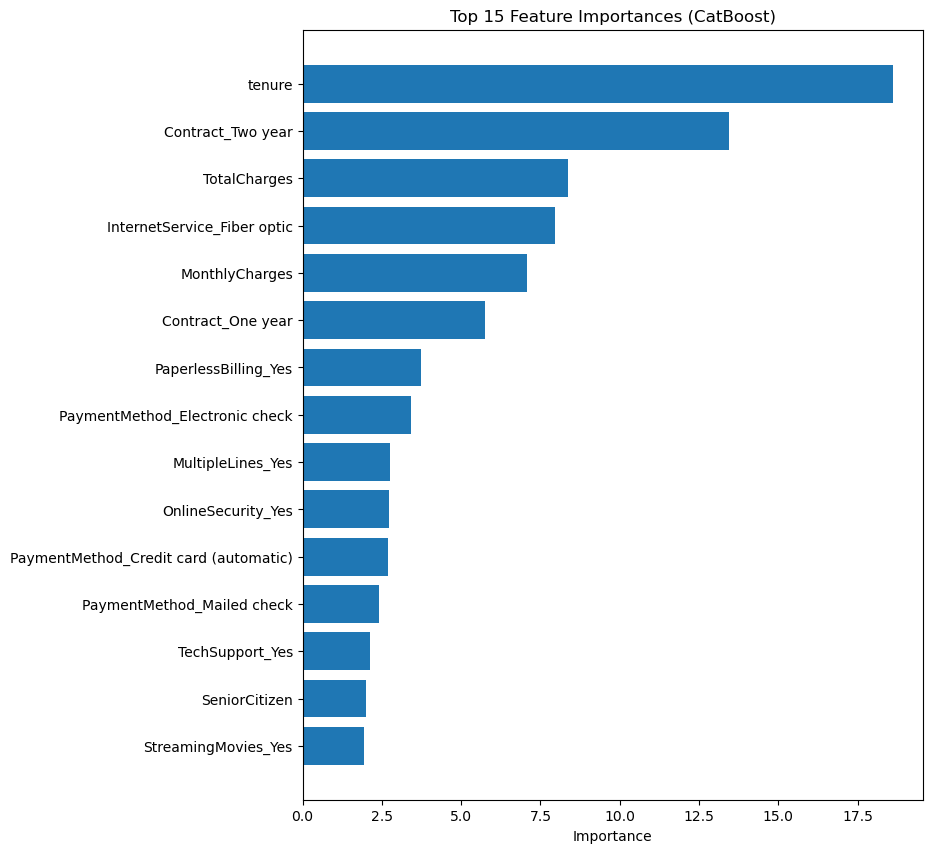

In [43]:
import matplotlib.pyplot as plt

importances = best_model.get_feature_importance()
feature_names = X_train_encoded.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_imp_df)

plt.figure(figsize=(8, 10))
plt.barh(feat_imp_df['Feature'][:15], feat_imp_df['Importance'][:15])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (CatBoost)')
plt.xlabel('Importance')
plt.show()

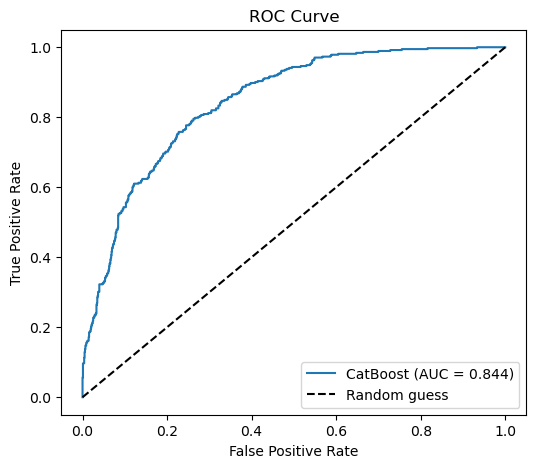

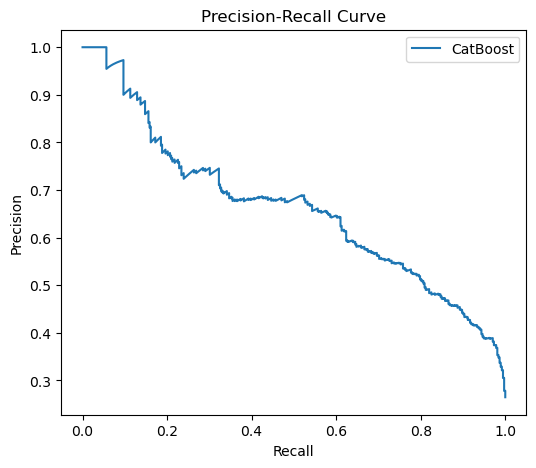

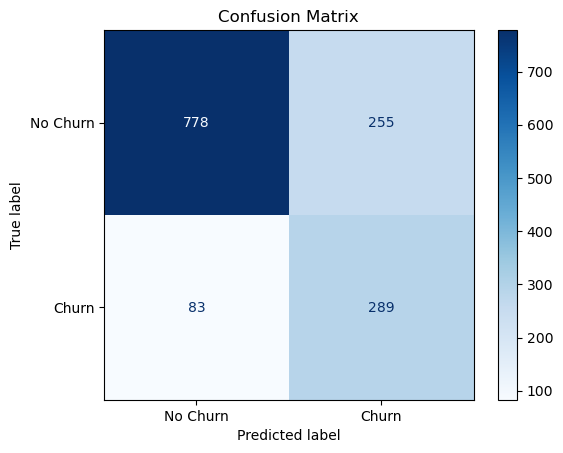

              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1033
       Churn       0.53      0.78      0.63       372

    accuracy                           0.76      1405
   macro avg       0.72      0.77      0.73      1405
weighted avg       0.81      0.76      0.77      1405



In [46]:
y_pred = best_model.predict(X_test_encoded)
y_proba = best_model.predict_proba(X_test_encoded)[:, 1]

# --- ROC-AUC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label='CatBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# --- Classification Report ---
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

deployment

In [52]:
import pickle

# Save model, scaler, and column structure
with open('catboost_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('columns.pkl', 'wb') as f:
    pickle.dump(X_train_encoded.columns.tolist(), f)

# Load and predict on new data
def predict_churn(new_customer_dict):
    new_df = pd.DataFrame([new_customer_dict])
    new_df = pd.get_dummies(new_df)
    new_df = new_df.reindex(columns=X_train_encoded.columns, fill_value=0)
    new_df[num_cols] = scaler.transform(new_df[num_cols])
    prediction = best_model.predict(new_df)[0]
    probability = best_model.predict_proba(new_df)[0][1]
    return {'Churn Prediction': 'Yes' if prediction == 1 else 'No', 'Churn Probability': round(probability, 3)}

In [54]:
import sys
print(sys.executable)

d:\anaconda\python.exe


In [55]:
print(sys.version)

3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
